make a project to clean data row to meangfull we have 100000 rows for practice
Raw Data
   ↓
1. Understand Data
   ↓
2. Clean Data
   ↓
3. Handle Missing Values
   ↓
4. Handle Duplicates
   ↓
5. Handle Outliers
   ↓
6. Convert Categorical Data
   ↓
7. Scale Numerical Data
   ↓
8. Select Features
   ↓
9. Split Data
   ↓
10. ML Model

before enter to ml we handle data clean it for deployment

Mounted at /content/drive
       customer_id   age  gender       city    education    income  orders  \
0          C197414  30.0    Male  Hyderabad     Bachelor   44227.0     8.0   
1          C109139  23.0  Female  Hyderabad      Diploma   52613.0     2.0   
2          C189079  25.0  Female  Hyderabad     Bachelor   67687.0    10.0   
3          C142333  16.0    Male     Mohali       Master   35938.0     7.0   
4          C136833  42.0  Female     Mohali     Bachelor   81094.0     8.0   
...            ...   ...     ...        ...          ...       ...     ...   
101995     C106266  21.0    Male  Hyderabad       Master   45818.0     2.0   
101996     C154887  38.0  Female        NaN     Bachelor   37806.0    10.0   
101997     C176821  18.0  Female    Panipat      Diploma   53552.0    10.0   
101998     C100861  23.0    Male     Mohali       Master   63,802      9.0   
101999     C115796  45.0    Male    Kolkata  High School   38474.0    14.0   

       total_spent  category      pay

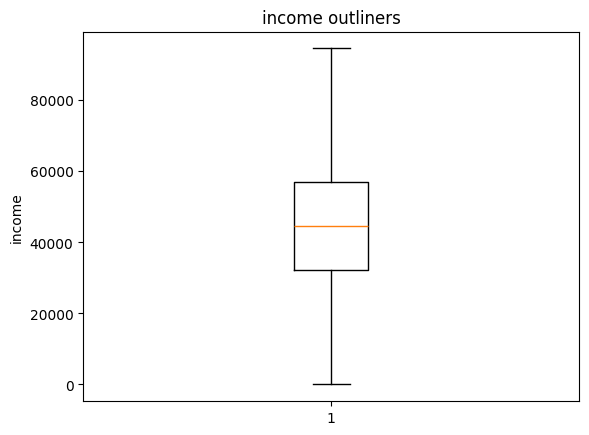

describe the first:
 count    100000.000000
mean      18941.891768
std       10375.069462
min           0.000000
25%       11542.167500
50%       17595.160000
75%       24934.142500
max       86574.840000
Name: total_spent, dtype: float64
mid value: 13391.975000000002
print the lower:
 -8545.795000000002
print the upper:
 45022.105
print the total_spent outliners value:
 Empty DataFrame
Columns: [customer_id, total_spent]
Index: []


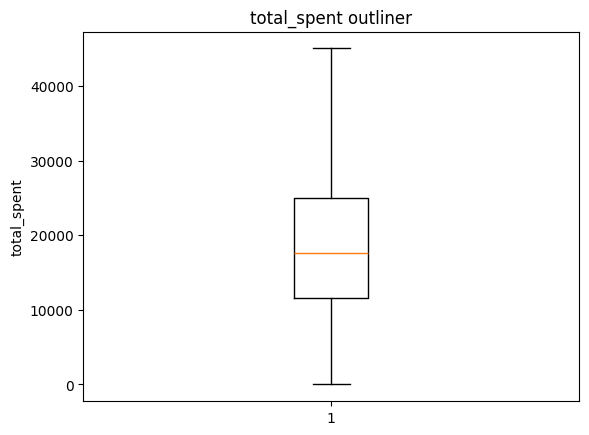

       customer_id   age  gender        city    education   income  orders  \
456        C132924  25.0  female   Hyderabad       Master  53094.0     0.0   
514        C184380  24.0  female       Delhi     Bachelor  47277.0     0.0   
592        C166092  24.0    male     Kolkata  High School  42407.0     0.0   
626        C150676  71.0  female      Mumbai      Diploma  59756.0     0.0   
767        C140849  40.0  female      Jaipur  High School  50893.0     0.0   
...            ...   ...     ...         ...          ...      ...     ...   
101311     C140263  51.0  female   Hyderabad     Bachelor  23476.0     0.0   
101454     C172370  38.0    male  Chandigarh     Bachelor  58573.0     0.0   
101679     C186832  35.0    male       Delhi  High School  54232.0     0.0   
101890     C113987  31.0  female      Mumbai       Master  68907.0     0.0   
101973     C125659  23.0  female      Mumbai     Bachelor  64403.0     0.0   

        total_spent     category      payment  discount  rating

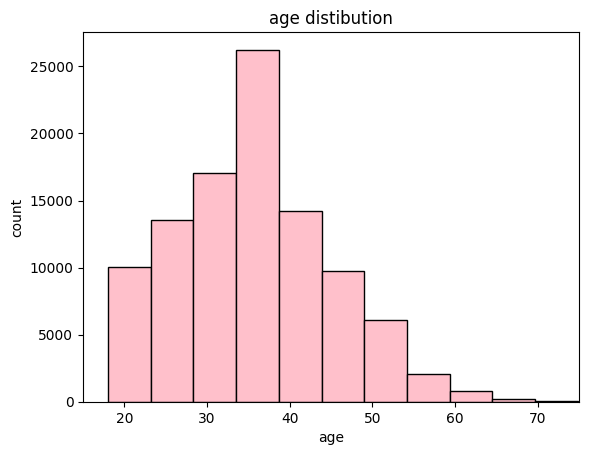

city
Delhi         9119
Chandigarh    9066
Hyderabad     9027
panipat       9025
Mumbai        9008
Chennai       8987
Pune          8962
Jaipur        8950
Bangalore     8947
Kolkata       8929
Mohali        8780
unknown       1200
Name: count, dtype: int64


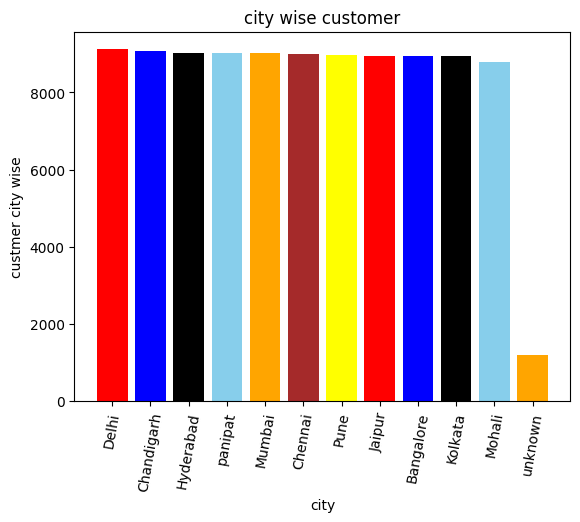

churn
No     91720
Yes     8280
Name: count, dtype: int64


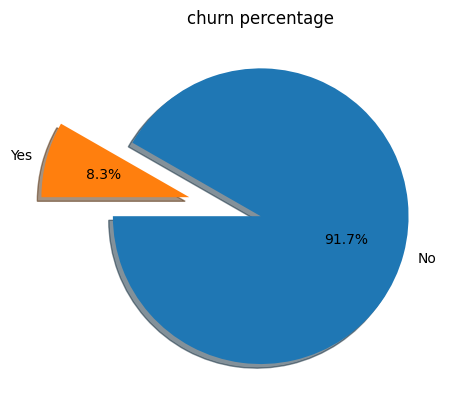

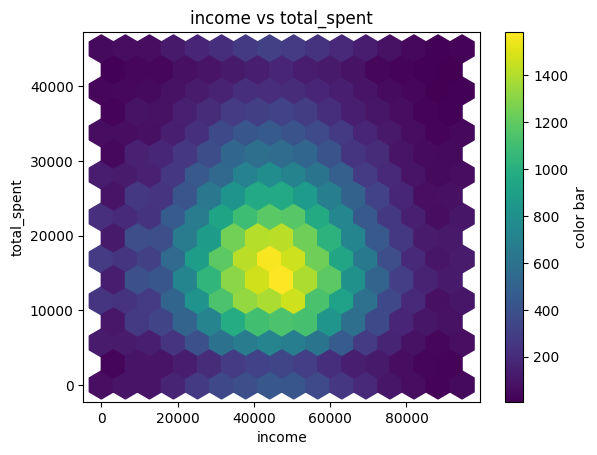

null value is:
 Unnamed: 0             0
customer_id            0
age                    0
gender                 0
city                   0
education              0
income                 0
orders                 0
total_spent            0
category               0
payment                0
discount               0
rating                 0
website_visits         0
support_calls          0
last_purchase          0
membership            92
churn                  1
spending_per_order     1
age_group              1
purchase_year          1
purchase_month         1
dtype: int64


In [1]:

from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## NUMPY
# first we import data we import csv file into dataframe in numpy
df =pd.read_csv("/content/drive/MyDrive/data_100k.csv")
print(df)
# this is used to chek our data is clean or not
# this is used to understand the data what we have,what is missing,what we do
print("shape of our data is:",df.shape)
print("chek the info :\n",df.info())
print("check null value in data:\n",df.isnull().sum())
print("check the duplicate value inside:\n",df.duplicated().sum())
print("describe is:\n",df.describe())

# ===============================

## fill the mising value used mean and forwerdfill
print("find the percentage missing value:\n",(df.isnull().sum() / len(df))*100)
df["age"] = df["age"].fillna(df["age"].median())
print("fill missing value with median of coloumn:")
df["gender"] =df["gender"].fillna(df["gender"].mode()[0])
print("fill mising gender value with most gender preference:\n")
print("fill city using word with unknown\n")
df["city"]=df["city"].fillna(df["city"].fillna("unknown"))
print("fill education using majorty type:\n")
df["education"]=df["education"].fillna(df["education"].mode()[0])
#print("fill income using unkown:\n",df["income"].fillna(df["income"].median()))
df['income'] = df['income'].fillna(0)
print("fill order using zero:\n")
df["orders"]= df["orders"].fillna(0)
#rint("total spent is :\n",df["total_spent"].fillna(df["total_spent"].mean()))
df['total_spent'] = df['total_spent'].fillna(0)
print("category fill with text:\n")
df["category"]=df["category"].fillna("not_specified")
print("fill payment using text:\n")
df['payment'] = df['payment'].fillna('Unknown')
print("fill membership is none:\n")
df['membership'] = df['membership'].fillna('None')
print("give rating to our nan using mean value")
df['rating'] = df['rating'].fillna(df['rating'].mean())
print("last purchase using date value")
df['last_purchase'] = df['last_purchase'].fillna(pd.to_datetime('2026-02-02'))


#==================================
# we check the the duplicate and remove it from my data base
print("chheck the duplicate value is:\n",df.duplicated().sum())
# we remove the duplicates value
print("remove the duplicate value from the file:\n")
df = df.drop_duplicates()
print("check null value in data:\n",df.isnull().sum())
print("chheck the duplicate value is:\n",df.duplicated().sum())


# ========================================
#we set data type into one data type like as
# we have income and total_spent like in diff form
# 4000
# ₹4000
# 4k
# 4,000
#we set all in one data type
# ==========================================
# first we convet into string data type to replace value in string easy
df["income"] = df["income"].astype(str)
# 2nd we reomve sign if any currency sign
df["income"] = df["income"].str.replace("₹","")
# 3rd we reeplace any comma
df["income"] = df["income"].str.replace(",", "")
# 4th we replace any char into int value for full
df["income"] = df["income"].str.replace("k","000")
df["total_spent"]= df["total_spent"].astype(str).str.replace("INR","")

# now we replace the datatyoe string to numeric
df["income"] = pd.to_numeric(df["income"])
# chexk the data type of our income
print("data type of income is:\n",df["income"].dtype)
# again fill nan value with mising value
#df['income'] = df['income'].fillna(df["income"].median())
print("check null value in data:\n",df.isnull().sum())

# total spent we correct it data type object to float
print("check data type: of difrent types in total_spent\n"
               ,df["total_spent"].value_counts().head(50))
#first we change the data type of column object to string for easy replace
df["total_spent"] = df["total_spent"].astype(str).str.strip().str.lower()
# first we change ₹ into blank
df["total_spent"] = df["total_spent"].str.replace("₹","")
# second we replace any comma to empty
df["total_spent"] = df["total_spent"].str.replace(",","")
# 3rd we replace the any char in our data
df["total_spent"] = df["total_spent"].str.replace("k","000")
# if we have any other like "inr"
df["total_spent"]= df["total_spent"].str.replace("inr","")
# we fill the nan value if occur
#df['total_spent'] = df['total_spent'].fillna(df["total_spent"].median())

# now we replace the datatyoe string to numeric
df["total_spent"] = pd.to_numeric(df["total_spent"])
# check the data type of total_spent
print("check the data type of total_spent:\n", df["total_spent"].dtype)

# ==============================================
# we handle categories data in my data base
#we have diffrent category can be in my data base
# Gender - male,female
# City - delhi,mumbai etc
# Depaet - hr,it,sales etc
# Eduation - post ,grad,school
# expeerience - low,high
# we handle like we have gender like- m,f,male,female let handle
# ==============================================

# """first we check the categorical data
# cat_colomns = df.select_dtype(include=["object","category"]).columns
# for col in cat_colomns:
#   print("colomn:",col)
#   print(df[col].unique())"""

# first we check the gender categorical data
# strip() is used to remove the extra space
# first we change into string for easy replace
df["gender"] = df["gender"].astype(str).str.strip().str.lower()
# now we replace the the unwanted type
df["gender"] = df["gender"].replace({
    "m":"male",
    "male":"male",
    "f":"female",
    "female":"female",
    "other":"other",
    "o":"other"
})
print("now we check:\n",df["gender"].value_counts())

# now we clean categorical city column
print("first we check the city types:\n",df["city"].value_counts())

# first we change into in string and convert into lower
df["city"] = df["city"].astype(str).str.strip().str.lower()

# now we replace the value
df["city"] = df["city"].replace({
    "delhi":"Delhi",
    "new delhi":"Delhi",
    "mumbai":"Mumbai",
    "bangalore":"Bangalore",
    "bengaluru":"Bangalore",
    "chennai":"Chennai",
    "kolkata":"Kolkata",
    "pune":"Pune",
    "hyderabad":"Hyderabad",
    "jaipur":"Jaipur",
    "chandigarh":"Chandigarh",
    "mohali":"Mohali",
    "sas nagar":"Mohali"
})
print("now we check after the replace right city name:\n",df["city"].value_counts())

# now we check the payment of categorical data
print("first we check the payment types:\n",df["payment"].value_counts())
# we handle payment in data we differ types payment let set all

# Wallet         16277
# Debit Card     16055
# Net Banking    16033
# UPI            15992
# Cash           15927
# Credit Card    15744
# Unknown         1000
# wallet           280
# NetBanking       268
# Wallet           259
# net banking      247
# DebitCard        231
# cash             229
#  CASH            227
# debit card       221
#  UpI             188
# CreditCard       178
# credit_card      167
# UPI              166
# upi              157
# credit card      154
# now we have this type let handle it

# 1st we chnange into string for easy rreplace
df["payment"] = df["payment"].astype(str).str.strip().str.lower()

# 2nd we chane all to set
df["payment"] = df["payment"].replace({
    "wallet":"Wallet",
    "debit card":"Debit Card",
    "net banking":"Net Banking",
    "credit card":"Credit Card",
    "upi":"Upi",
    "cash":"Cash",
    "debit_card":"Debit Card",
    "debitcard":"Debit Card",
    "credit_card":"Credit Card",
    "creditcard":"Credit Card",
    "net_banking":"Net Banking",
    "netbanking":"Net Banking",

})
print("now we check the payment after replace:\n",df["payment"].value_counts())

# now we handle the age if we have any age invalid like we check below
# ===========================
# some time we have value in age like
# -18
# 0
# 5
# 81+
# 150
# they are the invalid age normal is 18>= age <=180
# print("now we check the age:\n",df["age"].count_values())
# first we change all into numweric value
df["age"] = pd.to_numeric(df["age"])

# next we none the value which not btw the 18 to 80
# thats hepls us to easy to replace value btw 18 to 80
print("first check the invalid age:\n",df[(df["age"]<18) | (df["age"] > 80)])

# now we none invalid age
df.loc[(df["age"]<18) | (df["age"]> 80),"age"] = np.nan
# now we check the missing value for ig my code work
print("count the mising value in age:\n",df.isnull().sum())
# now we fill the missing value with median
df["age"] = df["age"].fillna(df["age"].median())
# now we gain chek the missing value
print("count the mising value in age:\n",df["age"].isnull().sum())

# ===================================
# we handle rating value our rating value is 1 to 5
# we chek our rating is no neg or mor than 5
# first we chnage type to numeric
df["rating"] = pd.to_numeric(df["rating"])
print("we check the invalid rating:\n",df[(df["rating"] < 1) | (df["rating"] > 5)])
# now we null the invalid rating
df.loc[(df["rating"] < 1) | (df["rating"] > 5),"rating"] = np.nan
print("we count the none value for my code check:\n",df["rating"].isnull().sum())
# we replac the value with medain of rating
df["rating"] = df["rating"].fillna(df["rating"].median())
print("now we check missing value is fill or not:\n",df["rating"].isnull().sum())

# ====================================
# now we clean the order can my order not in negative pd.value_counts
# first we convert intp numeric for replace
df["orders"] = pd.to_numeric(df["orders"])
# now we chek the invalid rating
print("now we check the invalid value:\n",df[df["orders"]<0])

# now we null the invalid order for fill in valid
df.loc[df["orders"]<0,"orders"] = np.nan
print("now we check the null value:\n",df["orders"].isnull().sum())
# now we fill the raitng value is valid with median
df["orders"] = df["orders"].fillna(df["orders"].median())
print("now we check the null valve is filled yrs or no:\n",
                          df["orders"].isnull().sum())

#=======================
# now we set the date like
# sometime we have date in diffrent type
# 1-1-2001
#1/1/2001
#2001-1-1
#2001/1/1
#jan 1 2001
# we have diffrent types of dates
# now we have in last purchase lets handel all

# now we fix into mixed format order
df["last_purchase"] = pd.to_datetime(df["last_purchase"],
                                     errors="coerce", format="mixed")
# now we check the datatype of dates
print("check the data type of lastpurchase:\n",df["last_purchase"].dtype)

# if we have a zero date and time can we handle it
print("we check the null date time:\n",df["last_purchase"].isnull().sum())

# now we fill the zero date and value with median
df["last_purchase"] = df["last_purchase"].fillna(
             df["last_purchase"].median())
print("now we check the null date time again:\n",df["last_purchase"].isnull().sum())

# =============================================
# now we handle the the outliers value in our data
# like we have very huge value in data is like
# 999999
# 25000000
# 5000000000
# 99999999999
# this value are the outlire very huge value
# let we hsndel using boxplot

# let we check the outliers in income
print("chek the outlires:\n",df["income"].describe())


# calculate outliers with formula
Q1 = df["income"].quantile(0.25)
Q2 = df["income"].quantile(0.75)

# we calculate the mid Q
# mid Q = Q2 - Q1
#its a mid value
IQR = Q2 - Q1
print(IQR)

lower = Q1 - 1.5 * IQR
upper = Q2 + 1.5 * IQR

print("print the lower:\n",lower)
print("print the upper:\n",upper)

# print the income outliers
income_outliers = df[(df["income"]<lower) | (df["income"] > upper)]
print("print the outliners of income:\n", income_outliers[["customer_id","income"]].head(20))

# instead delete the outliner we use to cap the outliner
# it limit the extreme value instead of deleting outliner data
df["income"] = df["income"].clip(
     lower =lower,
     upper = upper
)

# we can also show in boxplot model to show the income outliner
# make boxplot
plt.boxplot(df["income"].dropna(),label="income_line")
plt.title("income outliners")
plt.ylabel("income")
plt.show()
# we show in box plot we cap the outliner without deliting and we have mid value

# # ========================
# now we analyes the outlines of total spent
# we use the same boxplot model calulate the Q1,Q2,IQR values
print("describe the first:\n",df["total_spent"].describe())
# we have formula to check this

Q1 = df["total_spent"].quantile(0.25)
Q2 =  df["total_spent"].quantile(0.75)

# calculate the mid value IQR

IQR = Q2 - Q1
print("mid value:",IQR)

lower = Q1 - 1.5 * IQR
upper = Q2 + 1.5 * IQR

print("print the lower:\n",lower)
print("print the upper:\n",upper)

# now we check the outliners using lower or upper value

spent_outliners = df[(df["total_spent"]<lower) | df["total_spent"]>upper]
print("print the total_spent outliners value:\n",spent_outliners[
    ["customer_id","total_spent"]].head(20))

# now we cap the outliner if we have any instae od delete
df["total_spent"] = df["total_spent"].clip(
    lower = lower,
    upper = upper
)

# we can also show in boxplot model to show the total_outliner outliner
# make boxplot
plt.boxplot(df["total_spent"].dropna())
# give title
plt.title("total_spent outliner")
plt.ylabel("total_spent")
plt.show()
# we show in box plot we cap the outliner without deliting and we have mid value

# ============================================
# now we check the logical relationship btw coloumns
# like if we have order = 0 and spent is 50000
# its not a fair relationship
# we need to make sense to handle it

# let chek how we handle it
# first we check the relationship
print(df[
    (df["orders"]==0)
    & (df["total_spent"]>0)
])
# upper we check the relation btw orders and spent
# now we must 0 the value of total_spent which ave orders are also 0

df.loc[df["orders"]==0,"total_spent"] = 0
# again we check  we check the relationship
print(df[
    (df["orders"]==0)
    & (df["total_spent"]>0)
])

# now we chek our suport_cals or ewbsite not be zero
print(df[
    (df["support_calls"]<0) &
    (df["website_visits"]< 0)
])
# its fine now we check missin value again
print("check missing value:",df.isnull().sum())
# we have not any missing value if in case we have we use
# categorical and numeric_colomns use
# to fill all of them in both by one time with same operation

# we moving to data cleaning
#              to
#     data perpration

# in data prepration we make groups of age ,dates,spending

# firstwe make new row spending_per_order
# which tell us spendin by one order
# np.where we use to replce where our condititon stisfy

df["spending_per_order"] = np.where(
    df["orders"]>0,
    df["total_spent"] / df["orders"],0
)

print(df)

# now we prepare data in way
# we have age now we make age group now for make category to easy understand

# we use select function to apply condittions
df["age_group"] = np.select(
   [ df["age"] < 25,
     ((df["age"]< 25) | (df["age"] < 40)),
     ((df["age"] > 40) | (df["age"] < 60)),
     df["age"] >= 60],
   [
       "young",
       "adult",
       "middle_aged",
       "senior"
   ],
   default = "unknown"
)

print(df["age_group"])

# we create purchase year and month
df["purchase_year"] = df["last_purchase"].dt.year

# now we make the purchase month wise
df["purchase_month"] = df["last_purchase"].dt.month

# now we again check our data is clean properly
# we check it
print("shape of our data is:",df.shape)
print("chek the info :\n",df.info())
print("check null value in data:\n",df.isnull().sum())
print("check the duplicate value inside:\n",df.duplicated().sum())
print("describe is:\n",df.describe())

# our data is totaly clean and we save our clean data in new file
df["membership"] = df["membership"].fillna(df["membership"].mode(0))

'''df.to_csv("clean_data_100k.csv")
print(df)
# save file in our device
files.download("clean_data_100k.csv")'''
# ===============================
# firstly we visulize or dta through graphs
# we make a diffrent graphs or charts for understand data clearly data
# ==============================

# first we make histogram
# we take age,income,rating

plt.hist(df["age"],bins =12,color = "pink", edgecolor ="black")
plt.title("age distibution")
plt.xlabel("age")
plt.xlim(15,75)
plt.ylabel("count")
plt.show()

# we make a bar chart to compare the category of this data
# here we make a value counts of city wise unique
#here we use the one side is index value and in a-axis side we use citys
count_city = df["city"].value_counts()
print(count_city)

plt.bar(count_city.index, count_city.values,color=["red","blue","black",
                                  "skyblue","orange","brown","yellow"])


plt.title("city wise customer")
plt.xlabel("city")
plt.ylabel("custmer city wise")
plt.xticks(rotation = 80)
plt.show()

# now we compare the percentege with pie chart
churn = df["churn"].value_counts()
print(churn)
plt.pie(churn.values, labels = churn.index, autopct= "%1.1f%%",
        shadow=True, startangle= 180,explode=[0,0.5])

plt.title("churn percentage")
plt.show()

# now we make scater plot to display my data in simple way

plt.hexbin(df["income"],
            df["total_spent"],
            gridsize=15)
plt.colorbar(label="color bar")
plt.title("income vs total_spent")
plt.xlabel("income")
plt.ylabel("total_spent")
plt.show()


# now we make a data clean for our ml model
''' vizulize our data also
we do step in our data cleaning process is
    1 data see - see our data in which type wich is given or not

    2 see missing value in data
    handel missig value with mean, median , mode or another default value_counts

    3 seethe duplicates value in data and drpp duplicates value i our data

    4 handle numerical and categorical data
     like clean - invalid age, income , total spent ,dates , orders, rating
     handle all type of invalid value in data numericly or categriocly

    5 handle the outliers in our data
     handle any unexpected value in data
     handle it with boxplot model
     set the upper and lower value and
     cap the outlier iinstead delete

    6 next we prepare our data make data in groups
    thats make easy to understand us like - age group, etc

    7 last we visulaise our data in graps and chats form to show the relation
     it make easy to us to understand our data

    8 we save our clean data in in new name file and we
    will use in our ml model'''
df = pd.read_csv("clean_data_100k.csv")

print("null value is:\n",df.isnull().sum())





now we shiftig in ml

we here split our data train and test our data using

diffrent algorithm use we have many algo


In [2]:
# first we import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import ml models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import joblib

# import our clean file
df = pd.read_csv("clean_data_100k.csv")

# Handle DtypeWarning: Columns (6,8) have mixed types.
# Convert 'income' and 'total_spent' to numeric, coercing errors
df['income'] = pd.to_numeric(df['income'], errors='coerce')
df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

# Fill any new NaNs created by 'coerce' or existing NaNs for numerical features.
# The previous cell handled NaNs, but CSV save/load can sometimes reintroduce them or misinterpret types.
# Based on the output, 'discount', 'rating', 'website_visits', 'support_calls', 'spending_per_order'
# each have 1 null. 'membership' has 1768 nulls. 'churn' has 1 null.

for col in ['income', 'total_spent', 'discount', 'rating', 'website_visits', 'support_calls', 'spending_per_order']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Handle categorical NaNs for 'membership'
if df['membership'].isnull().any():
    df['membership'] = df['membership'].fillna(df['membership'].mode()[0])

# Convert 'churn' to numerical (0/1).
# If 'churn' has NaN, fill it before mapping. Based on output, it has 1 NaN.
if df['churn'].isnull().any():
    # Assuming 'No' is the majority class if NaN occurs, or a reasonable default
    df['churn'] = df['churn'].fillna(df['churn'].mode()[0])
df['churn'] = df['churn'].map({'No': 0, 'Yes': 1})

print(df.head())
print(df.shape)
print(df.info())

print("null value is",df.isnull().sum())




   Unnamed: 0 customer_id   age  gender       city education   income  orders  \
0           0     C197414  30.0    male  Hyderabad  Bachelor  44227.0     8.0   
1           1     C109139  23.0  female  Hyderabad   Diploma  52613.0     2.0   
2           2     C189079  25.0  female  Hyderabad  Bachelor  67687.0    10.0   
3           3     C142333  35.0    male     Mohali    Master  35938.0     7.0   
4           4     C136833  42.0  female     Mohali  Bachelor  81094.0     8.0   

   total_spent  category  ... rating  website_visits  support_calls  \
0     32936.78    Sports  ...    3.9              13              1   
1      6927.52    Sports  ...    1.2              19              1   
2     29909.62  Clothing  ...    3.6              19              2   
3     33526.08     Books  ...    5.0              18              5   
4     20996.31    Sports  ...    4.2              17              1   

   last_purchase  membership churn spending_per_order    age_group  \
0     2024-09-14

"joblib.dump(model, 'logistic_churn_prediction_model.pkl')"

In [3]:
# now we create x and y
X = df.drop("churn",axis=1)
y = df["churn"]


X = pd.get_dummies(X, drop_first=False)
X = X.astype(float)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

scaler = StandardScaler()

# transform our data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.impute import SimpleImputer # Add this import

model = LogisticRegression(max_iter=1000)

# Impute NaN values in the scaled data
imputer = SimpleImputer(strategy='mean') # You can change strategy to 'median' if preferred
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

model.fit(X_train_scaled, y_train)

# now we mke the prediction
y_pred = model.predict(X_test_scaled)

print("there is the prediction :\n",y_pred)

# check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("accuracy is:",accuracy)

# classificatin report is

print(classification_report(y_test,y_pred))
# it check the precision nad recall


#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

there is the prediction :
 [0 0 0 ... 0 0 0]
accuracy is: 0.9119623655913979
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1360
           1       0.00      0.00      0.00       128

    accuracy                           0.91      1488
   macro avg       0.46      0.50      0.48      1488
weighted avg       0.84      0.91      0.87      1488

[[1357    3]
 [ 128    0]]


Text(0, 0.5, 'True Labels')

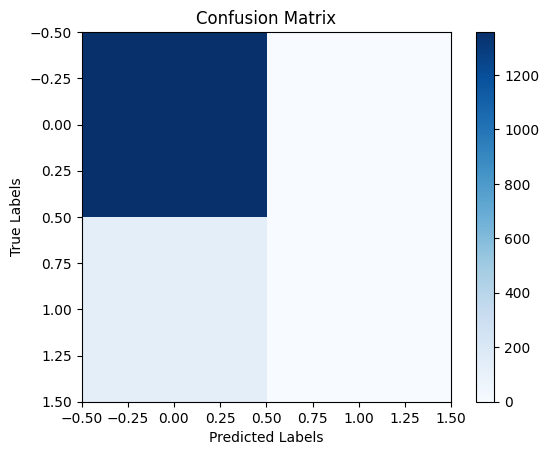

In [8]:
#we can visualize the problem
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')


In [14]:
# KNN algorithm used
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer # Ensure SimpleImputer is imported

model_knn = KNeighborsClassifier()

# now train our model
model_knn.fit(X_train_scaled,y_train)

# predict the model
y_pred = model_knn.predict(X_test_scaled)
print(y_pred)

# check the accuracy
print(accuracy_score(y_test,y_pred))

# check metrics
km = confusion_matrix(y_test,y_pred)
print(km)

# check the cross validatin for
# Impute NaN values in X before cross-validation
imputer_cv = SimpleImputer(strategy='mean')
X_imputed_cv = imputer_cv.fit_transform(X)

scores = cross_val_score(model_knn, X_imputed_cv, y, cv=10)

print(scores)
print(scores.mean())

[0 0 0 ... 0 0 0]
0.9112903225806451
[[1356    4]
 [ 128    0]]
[0.90860215 0.90188172 0.89919355 0.90725806 0.90994624 0.91263441
 0.90725806 0.90994624 0.90456989 0.90982503]
0.9071115356228022


In [11]:
# using Decesion Tree for predict model
from sklearn.tree import DecisionTreeClassifier

# create model
model_dt = DecisionTreeClassifier()
# fit our model
model_dt.fit(X_train_scaled,y_train)

# predict model
y_pred = model_dt.predict(X_test_scaled)
print(y_pred)

# check accuracy
print(accuracy_score(y_test,y_pred))

# check metrics
dm = confusion_matrix(y_test,y_pred)
print(dm)

[0 0 0 ... 0 0 0]
0.8904569892473119
[[1317   43]
 [ 120    8]]


In [13]:
# NAIVE BYES algorith use and check accuracy of our model
from sklearn.naive_bayes import GaussianNB

# make model
nb_model = GaussianNB()

# train our model
nb_model.fit(X_train_scaled,y_train)

# predict the model
y_pred = nb_model.predict(X_test_scaled)
print(y_pred)

# check acccuracy
print(accuracy_score(y_test,y_pred))

# check the metrics
print(confusion_matrix(y_test,y_pred))


[0 1 1 ... 1 0 1]
0.5443548387096774
[[776 584]
 [ 94  34]]


In [16]:
# save model
joblib.dump(model, 'logistic_churn_prediction_model.pkl')
joblib.dump(model_knn, 'KNN_churn_prediction_model.pkl')
joblib.dump(model_dt, 'DT_churn_prediction_model.pkl')

['DT_churn_prediction_model.pkl']

In [17]:
features_columns = X.columns.tolist()
print(features_columns)

joblib.dump(X.columns,"columns.pkl")
joblib.dump(scaler,"standard_scaler.pkl")

['Unnamed: 0', 'age', 'income', 'orders', 'total_spent', 'discount', 'rating', 'website_visits', 'support_calls', 'spending_per_order', 'purchase_year', 'purchase_month', 'customer_id_C100036', 'customer_id_C100054', 'customer_id_C100071', 'customer_id_C100088', 'customer_id_C100098', 'customer_id_C100103', 'customer_id_C100115', 'customer_id_C100128', 'customer_id_C100135', 'customer_id_C100150', 'customer_id_C100165', 'customer_id_C100187', 'customer_id_C100191', 'customer_id_C100200', 'customer_id_C100227', 'customer_id_C100251', 'customer_id_C100266', 'customer_id_C100271', 'customer_id_C100275', 'customer_id_C100279', 'customer_id_C100314', 'customer_id_C100324', 'customer_id_C100343', 'customer_id_C100363', 'customer_id_C100424', 'customer_id_C100438', 'customer_id_C100439', 'customer_id_C100467', 'customer_id_C100475', 'customer_id_C100477', 'customer_id_C100485', 'customer_id_C100492', 'customer_id_C100503', 'customer_id_C100506', 'customer_id_C100511', 'customer_id_C100547', '

['standard_scaler.pkl']